# **CS4168 Data Mining – Spotify Tracks Analysis**

Group Members:

- Sohaila Awaga (22367543)
- Oleksandr Kardash (22310975)
- Róisín Mitchell (21193762)
- Dara O’Malley (22349243)
- Katie Purser (22345477)

## **Exploratory Data Analysis (EDA)**
This section presents an exploratory data analysis of the ``tracks2026.csv`` dataset. The aim is to understand the structure, quality, and distributions of the data, while also identifying patterns that may inform the later clustering and predictive modelling tasks.

### **1. Glossary of Dataset Features**
The feature definitions below are adapted from the Spotify Tracks Dataset documentation on Hugging Face:
https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset

- ``track_id`` - Unique Spotify identifier for the track.

- ``popularity`` - Popularity score from 0 to 100, where higher values indicate more popular tracks.

- ``duration_ms`` - Track length in milliseconds.

- ``explicit`` - Indicates whether the track contains explicit lyrics.

- ``danceability`` - Measure of how suitable a track is for dancing, based on rhythm, tempo, and regularity. Values closer to 1 are more danceable.

- ``energy`` - Perceived intensity and activity of a track. Higher values usually indicate tracks that feel faster, louder, or noisier.

- ``key`` - Musical key of the track, represented numerically using pitch class notation.

- ``loudness`` - Overall loudness of the track in decibels (dB).

- ``mode`` - Modality of the track, where 1 represents major and 0 represents minor.

- ``speechiness`` - Measure of the presence of spoken words in a track. Higher values indicate more speech-like content.

- ``acousticness`` - Confidence measure of whether the track is acoustic. Higher values indicate greater likelihood that the track is acoustic.

- ``instrumentalness`` - Likelihood that the track contains no vocals. Higher values suggest a more instrumental track.

- ``liveness`` - Likelihood that the track was performed live. Higher values suggest a stronger live-recording presence.

- ``valence`` - Measure of musical positiveness. Higher values indicate a more positive or cheerful sound.

- ``tempo`` - Estimated speed of the track in beats per minute (BPM).

- ``time_signature`` - Estimated number of beats per bar.

- ``track_genre`` - Genre label assigned to the track.

In [509]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Load Dataset**

In [510]:
file_path = '../data/tracks2026.csv'
df = pd.read_csv(file_path)

df.head()

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


The dataset used in this project is ``tracks2026.csv``, which contains audio features and metadata for music tracks across multiple genres. These variables provide the basis for the exploratory, clustering, classification, and regression tasks that follow.

### **3. Dataset Overview**
In this section we take a look at the overall structure of the dataset, including its size, data types, and summary statistics.
Understanding these properties helps identify potential preprocessing steps the team will need to implement before later modelling tasks.

In [511]:
df.shape

(2000, 17)

The dataset contains **2000 rows and 17 columns** representing the audio tracks and their features.

In [512]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          2000 non-null   str    
 1   popularity        1960 non-null   float64
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   danceability      1960 non-null   float64
 5   energy            1960 non-null   float64
 6   key               2000 non-null   int64  
 7   loudness          1961 non-null   float64
 8   mode              2000 non-null   int64  
 9   speechiness       2000 non-null   float64
 10  acousticness      2000 non-null   float64
 11  instrumentalness  2000 non-null   float64
 12  liveness          2000 non-null   float64
 13  valence           2000 non-null   float64
 14  tempo             1960 non-null   float64
 15  time_signature    2000 non-null   int64  
 16  track_genre       2000 non-null   str    
dtypes: boo

The dataset contains numerical and categorical features.

Numerical features include:
- ``danceability``
- ``energy``
- ``loudness``
- ``tempo``
- ``acousticness``
- ``instrumentalness``

The feature ``track_genre`` is categorical and identifies the genre.
The feature ``popularity`` represents the popularity score.

In [513]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


The summary statistics show an overview of the central tendency, spread and range of the numeric features in the dataset.

**Features with good variation:**
- There is substantial variation in ``duration_ms``, ``tempo``, and ``popularity`` this dataset has meaningful diversity.
- The ``popularity`` feature ranges from 0 to 100 indicating a wide range of success across the tracks.

**Features with a smaller scale:**
- The features ``danceability``, ``energy``, and ``valence`` are on a smaller range between 0 and 1.

**Issues:**
- The feature ``loudness`` likely contains a data error. Most of the values are negative which is to be expected for decibels (the measurement of loudness), however the max value is 800000 which is unimaginably loud and physically impossible on planet earth (~130db is the point at which it causes pain to a human).

**Missing Values:**
- The columns ``popularity``, ``danceability``, ``energy``, ``loudness``, and ``tempo`` contain missing values as the counts are below 2000.

The summary statistics suggest that the dataset will need to be preprocessed before modelling.

### **4. Data Quality Checks**

In [514]:
df.isnull().sum()

track_id             0
popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            39
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

The dataset contains missing values in several numerical features.

Missing values:
- ``popularity`` (40)
- ``danceability`` (40)
- ``energy`` (40)
- ``loudness`` (39)
- ``tempo`` (40)

**The proportion of missing data is relatively small approximately 2%.**

The missing values occur in numerical audio features which are important for clustering and predictions. It is important that these are handled during preprocessing.

In [515]:
df[df['track_id'].duplicated(keep=False)][['track_id', 'track_genre', 'popularity']].sort_values('track_id')

,track_id,track_genre,popularity
689,0JBnAsReYppHqCZJbqy5H8,hip-hop,69.0
746,0JBnAsReYppHqCZJbqy5H8,pop,NaN
1476,0yc6Gst2xkRu0eMLeRMGCX,indie-pop,84.0
517,0yc6Gst2xkRu0eMLeRMGCX,pop,84.0
762,1K2RnVhm3eauKnA8PAcPu1,pop,74.0
...,...,...,...
1094,6ZmtxXUXRVjxOhugKkmerC,hip-hop,63.0
1281,75Ak0cit8hV604Wjlq1gf2,hip-hop,68.0
279,75Ak0cit8hV604Wjlq1gf2,pop,68.0
1218,7tZQznsUajYIVj4IwALXmz,pop,68.0


Some ``track_id`` values appear multiple times, and many of these duplicates occur across different genres. This suggests that the same track may be represented in more than one genre category, which should be considered when interpreting genre analysis and clustering results.

In total, the duplicate check reveals 64 rows involving repeated track_id values, representing 32 duplicated tracks, with many appearing under different genres.

### **5. Distribution of Key Features**

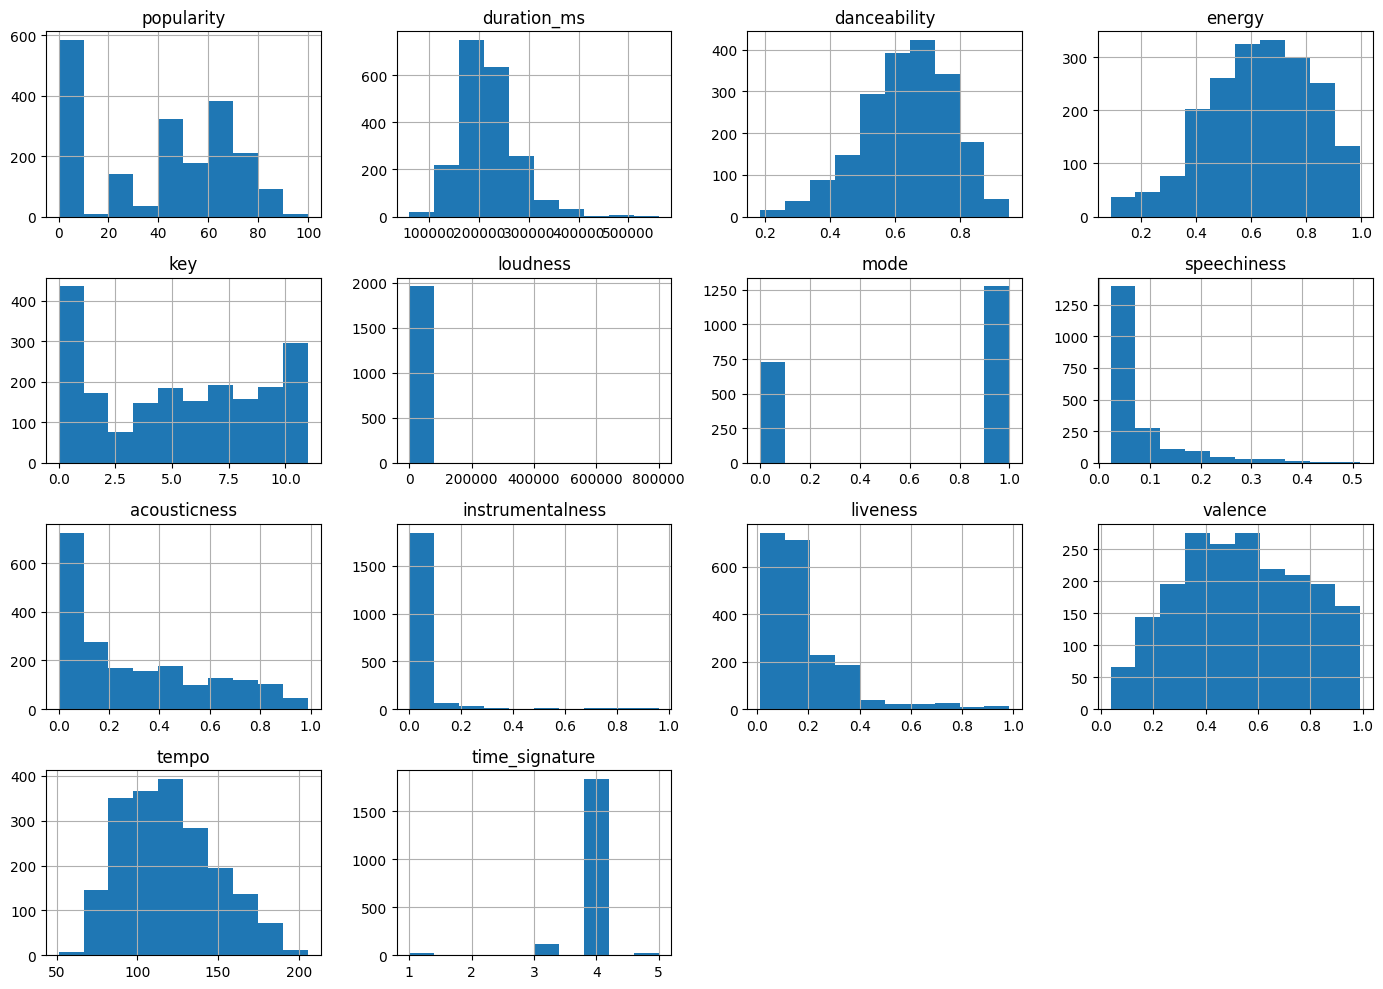

In [516]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

The histograms above show that the dataset contains a mixture of approximately symmetric, strongly skewed, and discrete-valued features.

**Smooth / Approximately Symmetric Features:**

These features appear relatively well distributed across their ranges, meaning they are less influenced by extreme values and may contribute more consistently to modelling.
- ``danceability``
- ``energy``  
- ``tempo`` 

**Strongly Right-Skewed Features:**

These features show strong right skew where most tracks have low values and only a small number of tracks have high values. They may still provide useful information, their skewed distributions suggest they should be interpreted carefully and could benefit from scaling or transformation.
- ``speechiness``  
- ``instrumentalness``  
- ``liveness``  
- ``acousticness``  

**Unevenly Distributed Features:**

Some features show uneven distributions, indicating that their values are concentrated in specific ranges rather than being evenly spread across the feature space. This may influence how strongly they contribute to modelling.
- ``key``  
- ``popularity``  

**Discrete-Valued Features:**

Several features represent discrete musical attributes rather than continuous measurements. These should be interpreted differently from continuous numeric features.

- ``mode``, ``time_signature``, and ``key`` are discrete variables.  
- ``time_signature`` is dominated by the value 4, which suggests limited variation and may reduce its usefulness as a predictive feature.

**Loudness:**

The histogram for ``loudness`` suggests there is a value with a data error or possible outlier, which supports the earlier observation that this feature may require further inspection or cleaning before modelling.

**Duration:**

The ``duration_ms`` feature shows that most tracks have durations around typical song lengths 2–4 minutes, with a smaller number of tracks having longer durations.



The histogram analysis shows that the dataset contains features with differing distributions and scales. This suggests that feature scaling, careful handling of skewed variables, and attention to low-variation features will be important during preprocessing before applying clustering or predictive models.

### **6. Outlier Analysis**

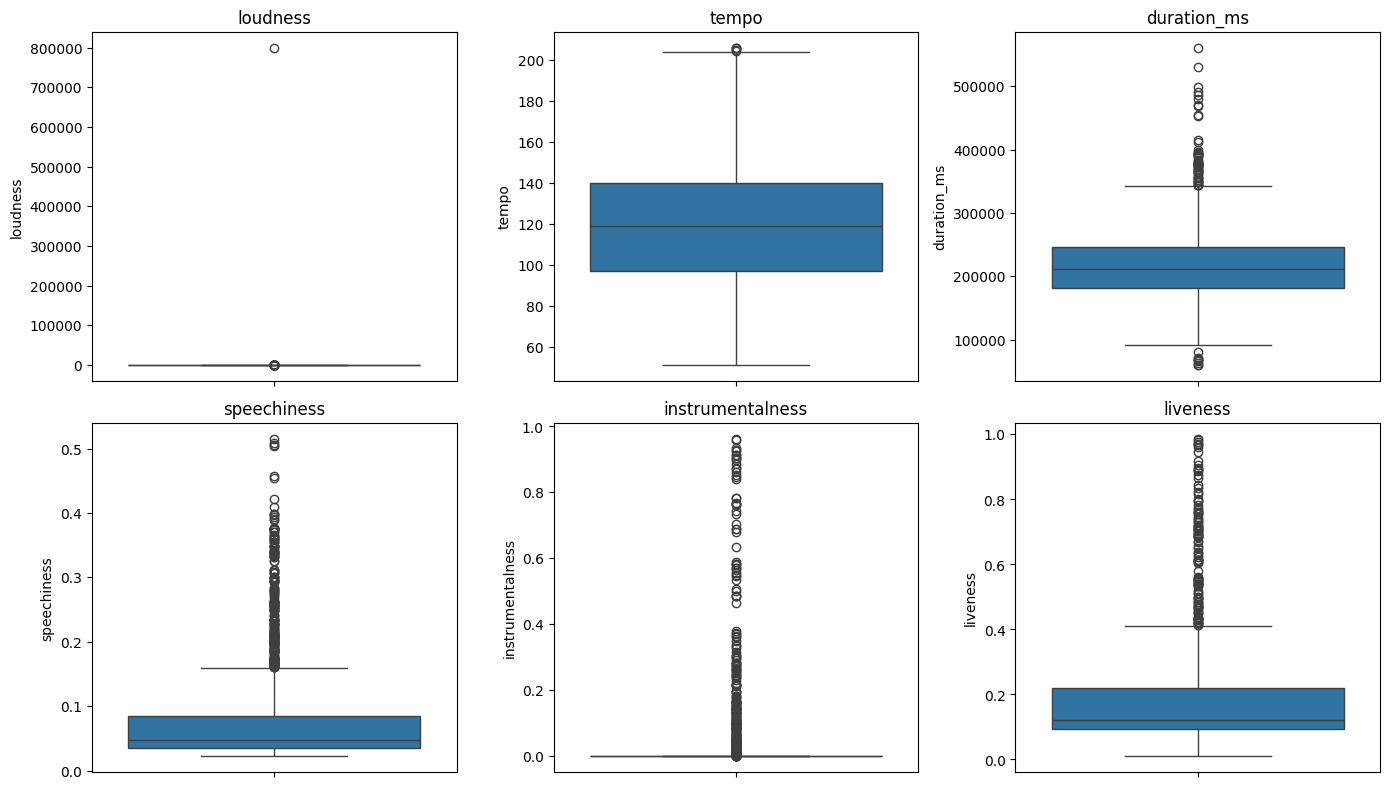

In [517]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))

features = ['loudness', 'tempo', 'duration_ms', 'speechiness', 'instrumentalness', 'liveness']

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

The boxplots show several outliers across the numerical features, especially in ``loudness``, ``duration_ms``, ``speechiness``, ``instrumentalness``, and ``liveness``. The extreme value in loudness is unrealistic and is likely an issue with the data quality. This is important because outliers can distort scaling and negatively affect distance-based methods like clustering which will be applied. Some extreme values may reflect genuine variation in music tracks, the loudness anomaly is large enough to justify separate investigation before modelling.

### **7. Correlation Analysis**

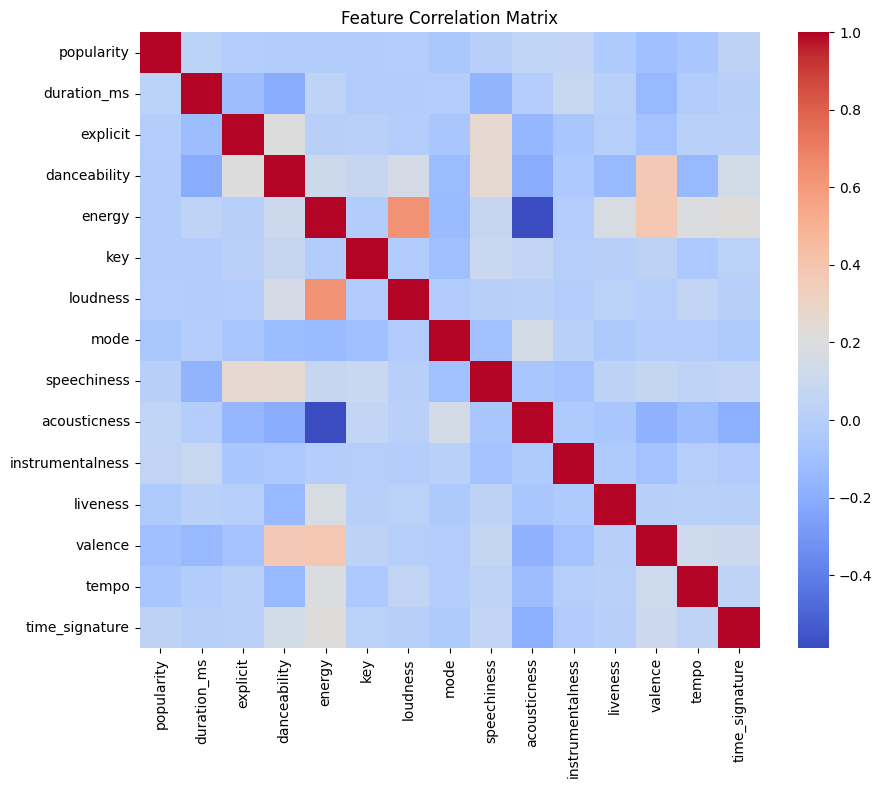

In [518]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

The correlation heatmap shows the relationships between numerical features in the dataset. In this heatmap most feature pairs show weak correlations, which indicates that many of the features capture different and complementary aspects of a track.

**Strong Positive Correlations:**

A strong positive correlation can be seen between ``energy`` and ``loudness``. This relationship is expected, as tracks with higher perceived energy generally have greater sound intensity levels.
A moderate positive relationship can seen between ``danceability`` and ``valence``, suggesting that tracks which are easier to dance to often have a more positive musical sound.

**Negative Correlations:**

There is a clear negative correlation between ``energy`` and ``acousticness``. This shows that high-energy tracks tend to be less acoustic in character.


**Weakly Correlated Features:**

Most other feature pairs display weak correlations, which suggests that many of the features capture different aspects of a track instead of overlapping heavily.
This is beneficial when modelling because it enables machine learning models to capture a wider range of information about each track.


**Popularity Relationships:**

The ``popularity`` feature does not show strong correlations with any individual audio feature. This suggests that track popularity is likely influenced by a combination of factors rather than a single characteristic.


The correlation analysis shows that the dataset contains many relatively distinct features, which supports their use as inputs for clustering and predictive modelling tasks.

### **8. Genre Analysis**

In [519]:
df['track_genre'].value_counts().head(10)

track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64

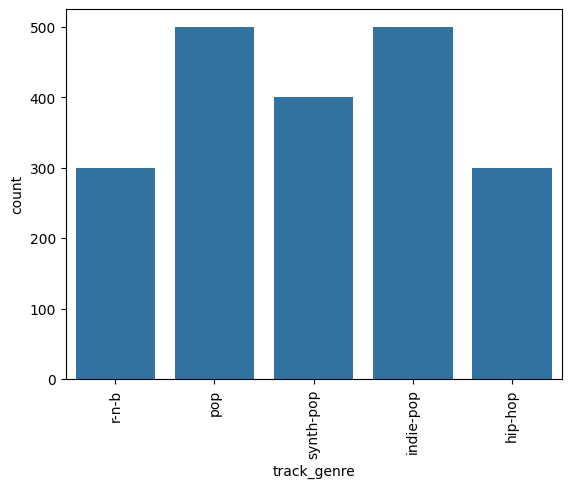

In [520]:
sns.countplot(data=df, x="track_genre")
plt.xticks(rotation=90)
plt.show()

The dataset contains five genres, where pop and indie-pop have the highest number of tracks, followed by synth-pop, while r-n-b and hip-hop have the lowest counts. 
The genre distribution is mostly balanced, which is useful for comparing patterns across genres without one category dominating the analysis. 
**This makes the dataset suitable for exploring whether different genres show distinct characteristics.**

### **9. Genre-wise Feature Comparisons**

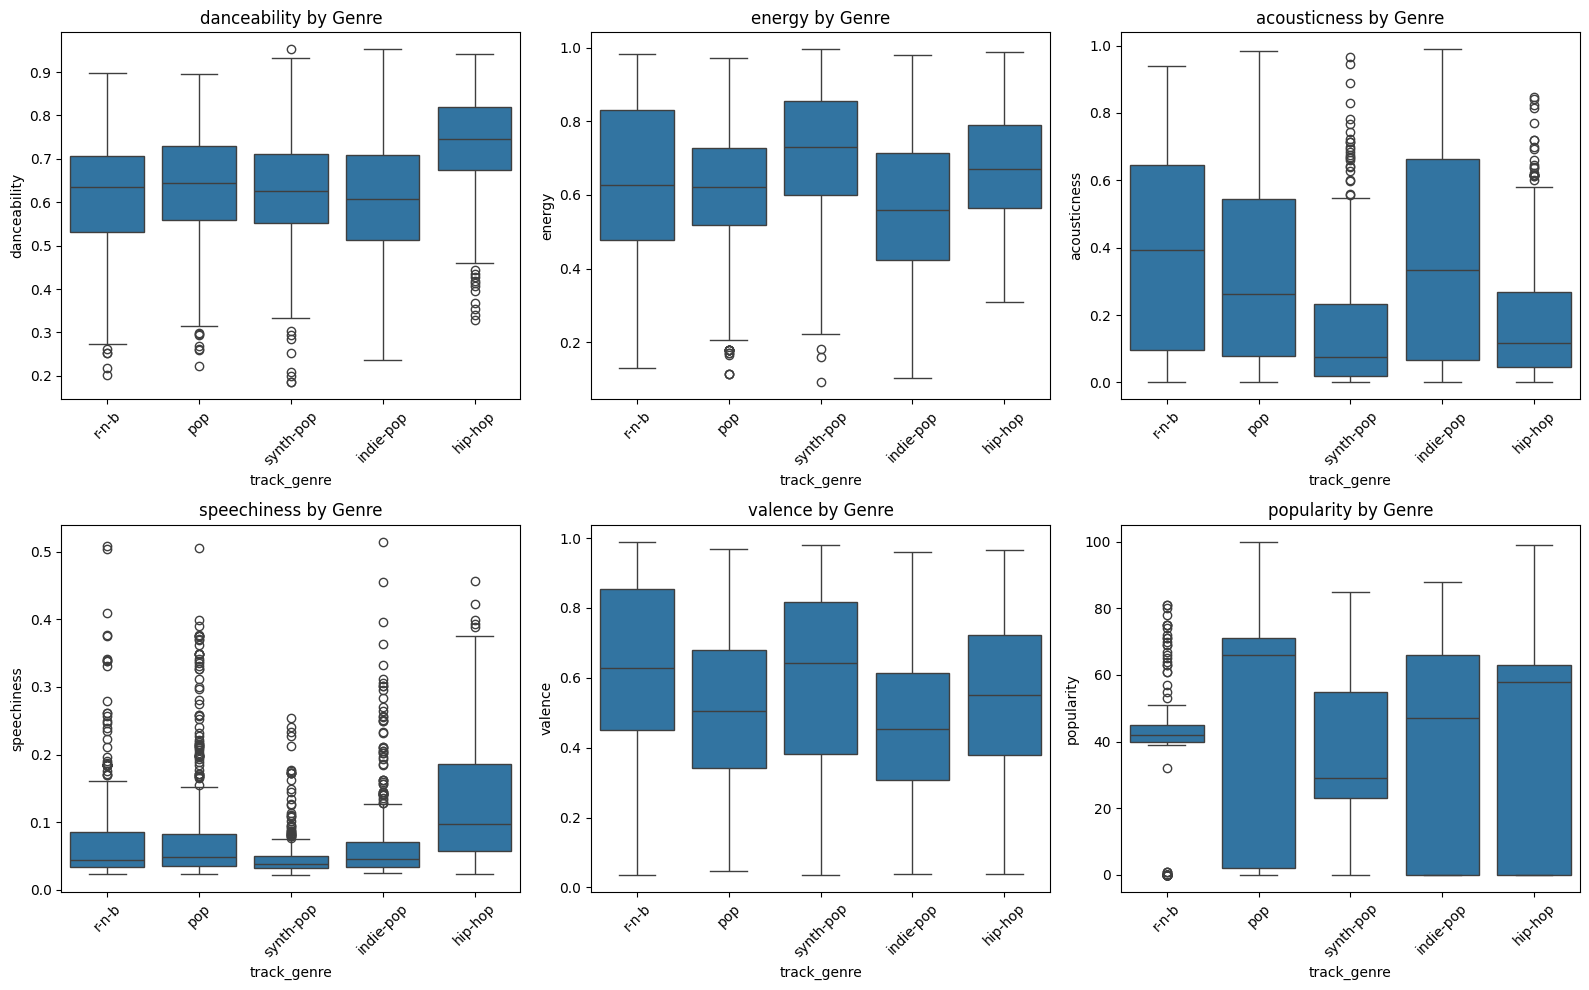

In [521]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))

features = ['danceability', 'energy', 'acousticness', 'speechiness', 'valence', 'popularity']

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='track_genre', y=feature, ax=ax)
    ax.set_title(f'{feature} by Genre')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The genre-wise boxplots show that while the genres overlap considerably, they also differ in several important audio features such as ``danceability``, ``energy``, ``acousticness``, ``speechiness``, and ``valence``. This suggests that genre-related structure exists in the dataset, which is encouraging for the later clustering task. However, the overlap between distributions indicates that the genres are unlikely to form perfectly separate groups.

In [522]:
df.groupby('track_genre')[['danceability', 'energy', 'acousticness', 'speechiness', 'valence', 'popularity']].mean()

,danceability,energy,acousticness,speechiness,valence,popularity
track_genre,,,,,,
hip-hop,0.732086,0.675627,0.188868,0.131810,0.548172,38.407534
indie-pop,0.603085,0.562490,0.378271,0.067337,0.469573,39.663968
pop,0.635467,0.611467,0.332349,0.081081,0.504443,46.190574
r-n-b,0.611973,0.635846,0.393219,0.079227,0.629715,35.894198
synth-pop,0.624043,0.712028,0.162051,0.048528,0.598879,36.007634


The grouped mean values support the boxplots by showing that genres differ in their average audio characteristics, even though substantial overlap remains between their full distributions.

### **10. EDA Summary**
The EDA shows that the dataset is generally suitable for analysis, but it will require some preprocessing before modelling. Missing data is limited to a small proportion of rows, while one extreme outlier/anomaly in ``loudness`` is likely to be a data-quality issue that should be handled carefully. 
The distributions of the numerical variables show differences in scale, skewness, and variation, which suggests that scaling and careful treatment of skewed features will be important. 
The correlation analysis indicates that most variables capture distinct aspects of a track, although a few meaningful relationships are present, such as those involving ``energy``, ``loudness``, and ``acousticness``. 
Finally, the genre-based analysis shows visible overlap between ``track_genre`` but also meaningful differences in several audio features, suggesting that clustering may recover some structure even if perfect separation is unlikely. ``Popularity``, however, does not appear to be strongly explained by any single feature, which suggests that predictive modelling may require combining multiple variables.